In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


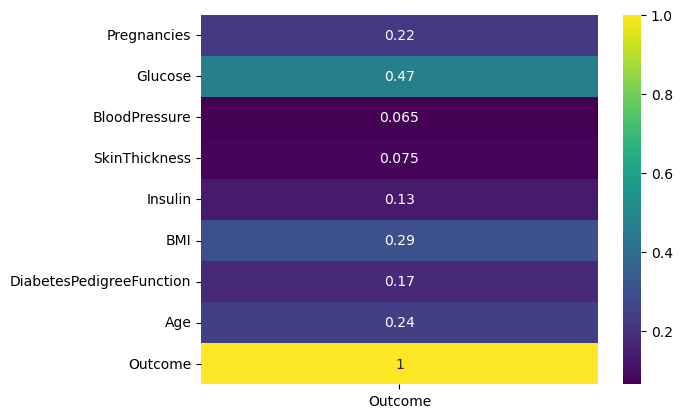

In [5]:
sns.heatmap(df.corr()[['Outcome']], annot=True , cmap='viridis')
plt.show()

In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']
print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)
print(f'X_train Shape -> {X_train.shape}')
print(f'X_test Shape -> {X_test.shape}')
print(f'y_train Shape -> {y_train.shape}')
print(f'y_test Shape -> {y_test.shape}')

X_train Shape -> (614, 8)
X_test Shape -> (154, 8)
y_train Shape -> (614,)
y_test Shape -> (154,)


In [10]:
# Scale the Input data
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.fit_transform(X_test)
print(X_train_scaled)

[[-0.52639686 -1.15139792 -3.75268255 ... -4.13525578 -0.49073479
  -1.03594038]
 [ 1.58804586 -0.27664283  0.68034485 ... -0.48916881  2.41502991
   1.48710085]
 [-0.82846011  0.56687102 -1.2658623  ... -0.42452187  0.54916055
  -0.94893896]
 ...
 [ 1.8901091  -0.62029661  0.89659009 ...  1.76054443  1.981245
   0.44308379]
 [-1.13052335  0.62935353 -3.75268255 ...  1.34680407 -0.78487662
  -0.33992901]
 [-1.13052335  0.12949347  1.43720319 ... -1.22614383 -0.61552223
  -1.03594038]]


In [92]:
# Let us build the ANN
import tensorflow
import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [16]:
model = Sequential()
model.add(Dense(32 , activation='relu',input_dim=8))
model.add(Dense(1 , activation='sigmoid'))

model.compile(loss='binary_crossentropy' , optimizer='Adam' , metrics=['accuracy'])
history = model.fit(X_train_scaled , y_train , validation_data=(X_test_scaled,y_test) , epochs=100 , batch_size=32)

Epoch 1/100


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6661 - loss: 0.6183 - val_accuracy: 0.7078 - val_loss: 0.5826
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7215 - loss: 0.5751 - val_accuracy: 0.7338 - val_loss: 0.5495
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7394 - loss: 0.5435 - val_accuracy: 0.7662 - val_loss: 0.5275
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7476 - loss: 0.5202 - val_accuracy: 0.7792 - val_loss: 0.5130
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7557 - loss: 0.5028 - val_accuracy: 0.7597 - val_loss: 0.5038
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7590 - loss: 0.4904 - val_accuracy: 0.7727 - val_loss: 0.4985
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7573 - loss: 0.4803 - val_accuracy: 0.7727 - val_loss: 0.4972
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7622 - loss: 0.4730 - val_accuracy: 0.7727 - val_loss: 0

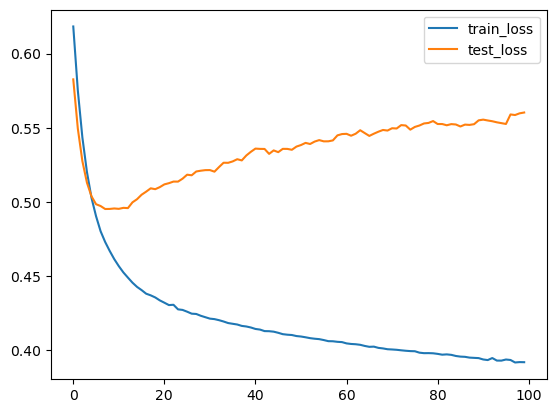

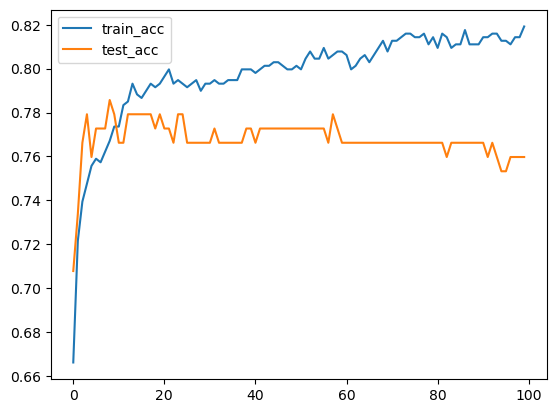

In [17]:
plt.plot(history.history['loss'] , label='train_loss')
plt.plot(history.history['val_loss'] , label='test_loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'] , label='train_acc')
plt.plot(history.history['val_accuracy'] , label='test_acc')
plt.legend()
plt.show()

- High Overfitting in the data

### Hyperparameter tuning in ANN Using Keras Tuner

In [28]:
import kerastuner as kt

### 1. How to select appropriate Optimizer?

In [ ]:

def build_model(hp):
    model = Sequential()
    model.add(Dense(32 , activation='relu',input_dim=8))
    model.add(Dense(1 , activation='sigmoid'))
    optimizer = hp.Choice('optimizers' , values = ['adam','sgd','rmsprop','adadelta','adagrad'])
    model.compile(loss='binary_crossentropy' , optimizer=optimizer , metrics=['accuracy'])
    return model

In [35]:
# ! pip install tensorboard

In [41]:
# make tuner object
tuner = kt.RandomSearch(build_model , objective='val_accuracy',max_trials=5 , overwrite=True)

tuner.search(X_train_scaled , y_train , epochs=5 , validation_data=(X_test_scaled , y_test))

Trial 5 Complete [00h 00m 02s]
val_accuracy: 0.7922077775001526

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 08s


In [42]:
tuner.results_summary()

Results summary
Results in .\untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 4 summary
Hyperparameters:
optimizers: rmsprop
Score: 0.7922077775001526

Trial 2 summary
Hyperparameters:
optimizers: adam
Score: 0.7727272510528564

Trial 0 summary
Hyperparameters:
optimizers: sgd
Score: 0.6818181872367859

Trial 3 summary
Hyperparameters:
optimizers: adadelta
Score: 0.6168830990791321

Trial 1 summary
Hyperparameters:
optimizers: adagrad
Score: 0.3571428656578064


In [44]:
# Get the best hyperparameters out of this
tuner.get_best_hyperparameters()[0].values

{'optimizers': 'rmsprop'}

In [51]:
# Get the best model directly 
best_model = tuner.get_best_models(num_models=1)[0]

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [52]:
best_model.fit(X_train_scaled , y_train , batch_size=32,validation_data=(X_test_scaled , y_test) , epochs=100 , initial_epoch=6)

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7590 - loss: 0.4986 - val_accuracy: 0.8052 - val_loss: 0.5043
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7687 - loss: 0.4839 - val_accuracy: 0.7987 - val_loss: 0.5006
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7655 - loss: 0.4752 - val_accuracy: 0.7857 - val_loss: 0.4971
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7622 - loss: 0.4682 - val_accuracy: 0.7857 - val_loss: 0.4934
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7638 - loss: 0.4621 - val_accuracy: 0.7792 - val_loss: 0.4918
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7752 - loss: 0.4573 - val_accuracy: 0.7792 - val_loss: 0.4914
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7752 - loss: 0.4543 - val_accuracy: 0.7727 - val_loss: 0.4931
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7785 - loss: 0.4506 - val_accuracy: 0.759

### Using BayesianOptimization instead of RandomSearch

In [56]:
# make tuner object
tuner = kt.BayesianOptimization(build_model , objective='val_accuracy',max_trials=5 , overwrite=True)

tuner.search(X_train_scaled , y_train , epochs=5 , validation_data=(X_test_scaled , y_test))

Trial 5 Complete [00h 00m 02s]
val_accuracy: 0.6753246784210205

Best val_accuracy So Far: 0.7467532753944397
Total elapsed time: 00h 00m 09s


In [57]:
tuner.get_best_hyperparameters()[0].values

{'optimizers': 'rmsprop'}

### 2. No. of nodes in a layer?

In [60]:
def build_model(hp):
    model = Sequential()
    unit = hp.Int('nodes' , min_value = 8 , max_value = 128)
    model.add(Dense(units=unit , activation='relu' , input_dim=8))
    model.add(Dense(1 , activation='sigmoid'))
    model.compile(loss='binary_crossentropy' , optimizer='rmsprop' , metrics=['accuracy'])
    return model

In [61]:
tuner = kt.RandomSearch(build_model , objective='val_accuracy',max_trials=5 , overwrite=True)
tuner.search(X_train_scaled , y_train , epochs=5 , validation_data=(X_test_scaled , y_test))

Trial 5 Complete [00h 00m 02s]
val_accuracy: 0.7857142686843872

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 09s


In [62]:
tuner.results_summary()

Results summary
Results in .\untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
nodes: 61
Score: 0.7922077775001526

Trial 4 summary
Hyperparameters:
nodes: 100
Score: 0.7857142686843872

Trial 2 summary
Hyperparameters:
nodes: 33
Score: 0.7272727489471436

Trial 0 summary
Hyperparameters:
nodes: 23
Score: 0.701298713684082

Trial 1 summary
Hyperparameters:
nodes: 13
Score: 0.6363636255264282


In [65]:
print(tuner.get_best_hyperparameters()[0].values)
model = tuner.get_best_models(num_models=1)[0]
model.fit(X_train_scaled , y_train , epochs=100 , validation_data=(X_test_scaled , y_test), initial_epoch=6)

{'nodes': 61}
Epoch 7/100


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7508 - loss: 0.5274 - val_accuracy: 0.7857 - val_loss: 0.5179
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7590 - loss: 0.5033 - val_accuracy: 0.7792 - val_loss: 0.5074
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7638 - loss: 0.4893 - val_accuracy: 0.7792 - val_loss: 0.5019
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7704 - loss: 0.4792 - val_accuracy: 0.7792 - val_loss: 0.4979
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7704 - loss: 0.4719 - val_accuracy: 0.7792 - val_loss: 0.4978
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7801 - loss: 0.4656 - val_accuracy: 0.7857 - val_loss: 0.4978
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7801 - loss: 0.4607 - val_accuracy: 0.7857 - val_loss: 0.4989
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.4569 - val_accuracy: 0.7792 - val_loss

### Using BayesianOptimization

In [68]:
tuner = kt.BayesianOptimization(build_model , objective='val_accuracy',max_trials=20 , overwrite=True)
tuner.search(X_train_scaled , y_train , epochs=5 , validation_data=(X_test_scaled , y_test))

Trial 20 Complete [00h 00m 02s]
val_accuracy: 0.7857142686843872

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 40s


In [69]:
print(tuner.get_best_hyperparameters()[0].values)
model = tuner.get_best_models(num_models=1)[0]
model.fit(X_train_scaled , y_train , epochs=100 , validation_data=(X_test_scaled , y_test), initial_epoch=6)

{'nodes': 90}
Epoch 7/100


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7655 - loss: 0.4787 - val_accuracy: 0.7857 - val_loss: 0.5062
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7769 - loss: 0.4666 - val_accuracy: 0.7987 - val_loss: 0.5053
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7720 - loss: 0.4605 - val_accuracy: 0.7922 - val_loss: 0.5038
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7785 - loss: 0.4557 - val_accuracy: 0.7922 - val_loss: 0.5061
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7720 - loss: 0.4521 - val_accuracy: 0.7922 - val_loss: 0.5051
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7801 - loss: 0.4485 - val_accuracy: 0.7857 - val_loss: 0.5085
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7801 - loss: 0.4457 - val_accuracy: 0.7857 - val_loss: 0.5100
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.4439 - val_accuracy: 0.7662 - val_loss

### 3. No. of layers in ANN?


In [75]:
def build_model(hp):
    model = Sequential()
    # First hidden layer default to decrease complexity
    model.add(Dense(72 , activation='relu',input_dim=8))

    # now we loop from 1 layer to 10 extra hidden layers each of 72 nodes
    for i in range(hp.Int('num_layers' , min_value=1 , max_value=10)):
        model.add(Dense(72 , activation='relu'))
    model.add(Dense(1 , activation='sigmoid')) # final layer with sigmoid

    model.compile(loss='binary_crossentropy' , optimizer='rmsprop' , metrics=['accuracy'])
    return model

In [78]:
tuner = kt.BayesianOptimization(build_model , objective='val_accuracy',max_trials=5 , overwrite=True)
tuner.search(X_train_scaled , y_train , epochs=5 , validation_data=(X_test_scaled , y_test))

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.7857142686843872

Best val_accuracy So Far: 0.7857142686843872
Total elapsed time: 00h 00m 14s


In [79]:
tuner.get_best_hyperparameters()[0].values # so the best we got is 1 layer as dataset is pretty easy

{'num_layers': 9}

In [80]:
model = tuner.get_best_models(num_models=1)[0]
model.fit(X_train_scaled,y_train,epochs=100,initial_epoch=6,validation_data=(X_test_scaled,y_test))

Epoch 7/100


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7785 - loss: 0.4708 - val_accuracy: 0.7727 - val_loss: 0.5478
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7769 - loss: 0.4465 - val_accuracy: 0.7078 - val_loss: 0.5634
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7866 - loss: 0.4374 - val_accuracy: 0.7403 - val_loss: 0.5634
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8013 - loss: 0.4283 - val_accuracy: 0.7532 - val_loss: 0.5837
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8127 - loss: 0.4102 - val_accuracy: 0.7013 - val_loss: 0.6858
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8257 - loss: 0.4012 - val_accuracy: 0.7532 - val_loss: 0.5740
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8143 - loss: 0.3907 - val_accuracy: 0.7273 - val_loss: 0.5436
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8306 - loss: 0.3912 - val_accuracy: 0.6688 - val_los

### 4. All In One Model

In [100]:
def build_model(hp):
    model = Sequential()
    counter =0
    for i in range(hp.Int('layers' , min_value = 1 , max_value=10)):
        if counter==0: # first hidden layer (to add input_dim here)
            model.add(Dense(
                hp.Int('nodes' + str(i) , min_value=8 , max_value = 128),
                activation = hp.Choice('activations' + str(i) , values = ['relu','tanh','sigmoid']),
                input_dim = 8
            ))
            model.add(Dropout(hp.Choice('dropouts'+str(i) , values = [0.1,0.2,0.3,0.5,0.6])))

        else: # mid hidden layers
            model.add(Dense(
                            hp.Int('nodes' + str(i) , min_value=8 , max_value = 128),
                            activation = hp.Choice('activations' + str(i) , values = ['relu','tanh','sigmoid'])
                        ))

            model.add(Dropout(hp.Choice('dropouts'+str(i) , values = [0.1,0.2,0.3,0.5,0.6])))
        counter+=1


    model.add(Dense(1 , activation='sigmoid')) # final layer

    model.compile(loss='binary_crossentropy',
                    metrics=['accuracy'],
                    optimizer = hp.Choice('optimizer' , values= ['adam','rmsprop','sgd','adamw','adagrad','adadelta'])
                    )
    return model
        

In [101]:
tuner = kt.RandomSearch(build_model , max_trials=5 , objective='val_accuracy' , overwrite=True)
tuner.search(X_train_scaled , y_train , epochs=5 , validation_data = (X_test_scaled , y_test))

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.6428571343421936

Best val_accuracy So Far: 0.6623376607894897
Total elapsed time: 00h 00m 17s


In [102]:
tuner.get_best_hyperparameters()[0].values

{'layers': 2,
 'nodes0': 23,
 'activations0': 'relu',
 'dropouts0': 0.1,
 'optimizer': 'adamw',
 'nodes1': 20,
 'activations1': 'sigmoid',
 'dropouts1': 0.5,
 'nodes2': 79,
 'activations2': 'sigmoid',
 'dropouts2': 0.5,
 'nodes3': 106,
 'activations3': 'relu',
 'dropouts3': 0.2,
 'nodes4': 41,
 'activations4': 'tanh',
 'dropouts4': 0.1,
 'nodes5': 125,
 'activations5': 'relu',
 'dropouts5': 0.5,
 'nodes6': 78,
 'activations6': 'relu',
 'dropouts6': 0.2,
 'nodes7': 22,
 'activations7': 'sigmoid',
 'dropouts7': 0.3,
 'nodes8': 15,
 'activations8': 'relu',
 'dropouts8': 0.5,
 'nodes9': 47,
 'activations9': 'sigmoid',
 'dropouts9': 0.2}

In [103]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.fit(X_train_scaled , y_train , epochs=100 , initial_epoch=6 , validation_data=(X_test_scaled , y_test))

Epoch 7/100


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6824 - loss: 0.5965 - val_accuracy: 0.6688 - val_loss: 0.5668
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6710 - loss: 0.6058 - val_accuracy: 0.7208 - val_loss: 0.5563
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6645 - loss: 0.5879 - val_accuracy: 0.7273 - val_loss: 0.5472
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7036 - loss: 0.5638 - val_accuracy: 0.7338 - val_loss: 0.5381
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7068 - loss: 0.5580 - val_accuracy: 0.7727 - val_loss: 0.5300
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7003 - loss: 0.5675 - val_accuracy: 0.7597 - val_loss: 0.5247
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7166 - loss: 0.5531 - val_accuracy: 0.7597 - val_loss: 0.5194
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7248 - loss: 0.5428 - val_accuracy: 0.7597 - val_loss